## 0️⃣ 1. Imports and style
- Load trained models
- Define spatial grid
- Set plotting utilities

In [2]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Figures
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "lines.linewidth": 2,
})

# Repo imports (assumes repo root is on PYTHONPATH)
from model import InverseSchrodingerModel
from utils import make_grid, set_global_seed
from physics import tise_loss, potential_smoothness_loss
from inverse import data_mismatch_loss
from pod import pod_decomposition

## 0️⃣ 2. Synthetic problem definition

In [3]:
set_global_seed(27)

# Spatial grid
x = make_grid(-5.0, 5.0, 256)       # (N,1)
dx = float(x[1] - x[0])

# Choose a known analytic potential (e.g., harmonic oscillator)
V_true = 0.5 * x.squeeze()**2       # shape (N,)

# Analytic eigenfunctions (Hermite-Gaussians) for illustration
def hermite_gauss(n, x):
    """Return the nth normalized harmonic oscillator eigenfunction."""
    from math import factorial, sqrt, pi
    import scipy.special as sp
    norm = 1.0 / sqrt(2.0**n * factorial(n)) * (pi**-0.25)
    return norm * sp.hermite(n)(x) * torch.exp(-0.5 * x**2)

psi_true = [hermite_gauss(n, x.squeeze()) for n in range(3)]
E_true = torch.tensor([0.5, 1.5, 2.5])  # exact energies (hbar = omega = 1)

# Observed data with some noise so the model has something to fit
rho_obs = [psi**2 + 0.02 * torch.randn_like(psi) for psi in psi_true]
E_obs = E_true + 0.05 * torch.randn_like(E_true)

## 0️⃣ 3. Small training loop

In [5]:
model = InverseSchrodingerModel(
    n_states=3,
    hidden_dims=[64, 64],
    device=torch.device("cpu"),
).to(torch.device("cpu"))

optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

lambdas = {"data": 1.0, "physics": 1.0, "smooth": 1e-2}

def train_one_epoch():
    optimizer.zero_grad()
    loss = (
        lambdas["data"] *
        data_mismatch_loss(
            model.psi_theta(x),
            model.E_theta(),
            rho_obs,
            E_obs,
        )
        + lambdas["physics"] *
        tise_loss(
            model.psi_theta(x),
            model.V_theta(x),
            model.E_theta(),
            dx,
        )
        + lambdas["smooth"] *
        potential_smoothness_loss(model.V_theta(x), dx)
    )
    loss.backward()
    optimizer.step()
    return loss.item()

# Run a short training to obtain something recognizable
loss_history = []
for epoch in range(500):        # ~1 sec on CPU
    loss_history.append(train_one_epoch())
    if epoch % 50 == 0:
        print(f"epoch {epoch:3d} - loss {loss_history[-1]:.4f}")

epoch   0 - loss 2.4934
epoch  50 - loss 1.8506
epoch 100 - loss 1.6694
epoch 150 - loss 1.0011
epoch 200 - loss 0.7345
epoch 250 - loss 0.5347
epoch 300 - loss 0.3875
epoch 350 - loss 0.2809
epoch 400 - loss 0.2049
epoch 450 - loss 0.1520


## 1️⃣ Figure 1: Training curve
### 📈 Plot
- Figure 1a: Total loss vs. epoch
- Optional: physics vs. data vs. smoothness (stacked or separate)

> 🏡 *"The inverse problem stabilizes under competing physical and data-driven objectives."*


In [6]:
# Figure 1 code

## 2️⃣ Figure 2: Learned potential

### 📈 Plot
- $V_\theta(x)$ vs. $x$
- Ground truth $V(x)$

### 💬 Messages
- Smoothness prior effect
- Identifiability limits
- Bias vs. variance tradeoff

### ✖️ Failure modes
- Flattening
- Over-smoothing
- Boundary artifacts

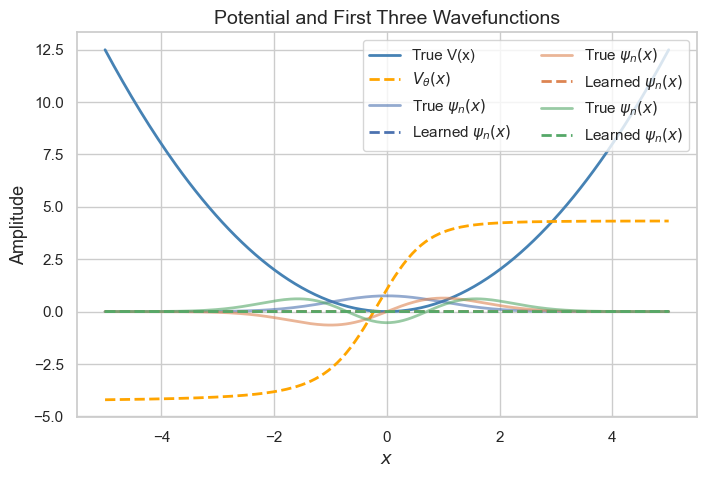

In [8]:
V_learned = model.V_theta(x).detach().squeeze()
psi_learned = [p.detach().squeeze() for p in model.psi_theta(x)]

fig, ax = plt.subplots()
ax.plot(x.squeeze(), V_true, label="True V(x)", color="steelblue", lw=2)
ax.plot(x.squeeze(), V_learned, "--", label=r"$V_\theta(x)$", color="orange")

colors = ["C0", "C1", "C2"]
for n, (psi_t, psi_l) in enumerate(zip(psi_true, psi_learned)):
    ax.plot(
        x.squeeze(),
        psi_t,
        label=rf"True $\psi_n(x)$",
        color=colors[n],
        alpha=0.6,
    )
    ax.plot(
        x.squeeze(),
        psi_l,
        "--",
        label=rf"Learned $\psi_n(x)$",
        color=colors[n],
    )

ax.set_xlabel(rf"$x$")
ax.set_ylabel("Amplitude")
ax.set_title("Potential and First Three Wavefunctions")
ax.legend(loc="upper right", ncol=2)
plt.show()

## 3️⃣ Figure 3: Learned wave function $\psi_n(\theta, x)$
### 📈 Plot
- Learned ${\psi_0}_\theta$, ${\psi_1}_\theta$ and ${\psi_2}_\theta$ (3 subplots)

### 💬 Messages
- Phase ambiguity
- Shape consistency
- Node Structure

> ✨ Do _not_ claim correctness; just structure.

In [ ]:
# figure 3

## 4️⃣ Figure 4: Energy spectrum comparison

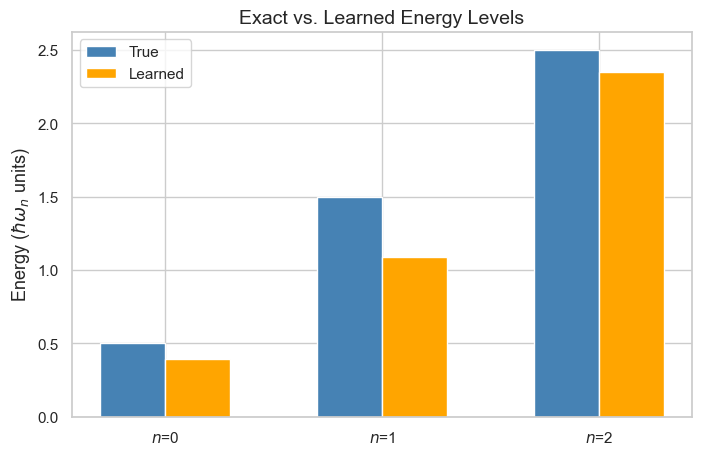

In [11]:
E_learned = model.E_theta().detach()

fig, ax = plt.subplots()
indices = torch.arange(len(E_true)).numpy()

ax.bar(indices - 0.15, E_true.numpy(), width=0.3, label="True", color="steelblue")
ax.bar(indices + 0.15, E_learned.numpy(), width=0.3, label="Learned", color="orange")

ax.set_xticks(indices)
ax.set_xticklabels([rf"$n$={i}" for i in indices])
ax.set_ylabel(rf"Energy ($\hbar \omega_n$ units)")
ax.set_title("Exact vs. Learned Energy Levels")
ax.legend()
plt.show()

## 5️⃣ Figure 5: Probability densities $|\psi_n(\theta, x)|^2$ vs. observations
- Plot
    -  $|\psi_n(x)|^2$
    - Observed $\rho_n(x)$
- Message
    - Data anchoring
    - Indirect supervision
    - Why phase remains unconstrained

In [12]:
# figure 5 code

## 6️⃣ Figure 6: Overlap matrix heatmap (POD diagnostic)
- Plot
    - Heatmap of $\langle \psi_m | \psi_n \rangle$
- Message
    - Near-orthogonality emerges (or not)
    - Coupling through shared $V(x)$
- ✨ This is very important for interpretability.

In [ ]:
# Figure 6 code

## 7️⃣ Figure 7: POD singular values
- Plot
    - Singular values $\sigma_k$ vs. $k$ (log scale)
- Message
    - Effective dimensionality
    - Redundant modes
    - Capacity vs. constraint
- Failure mode
    - One dominant singular value -> collapse (❓)

In [ ]:
# Figure 7 code

## 8️⃣ Figure 8: POD singular values and dominant modes 

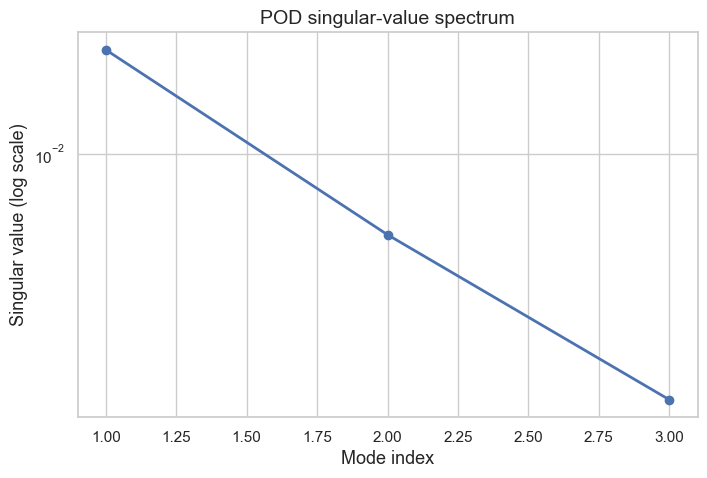

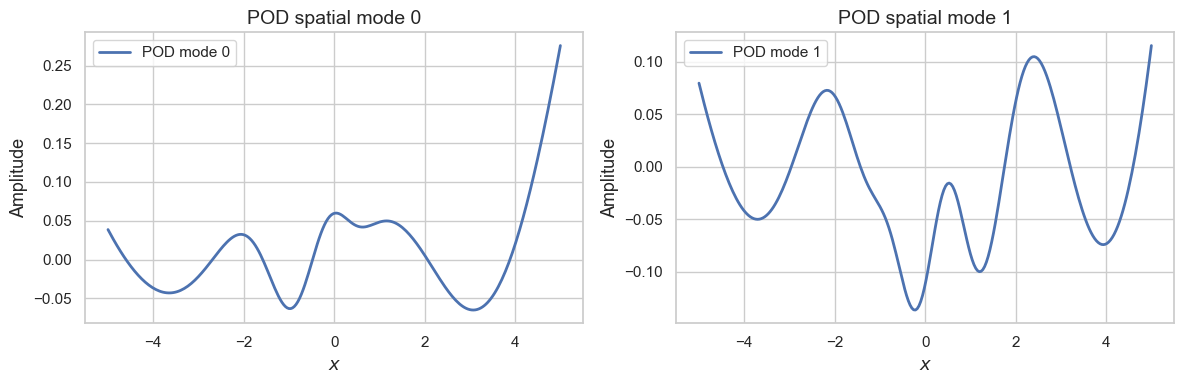

In [13]:
# Stack the learned wavefunctions column-wise to feed POD
psi_matrix = torch.stack(psi_learned, dim=1)    # shape (N, n_states)

U, S, Vh = pod_decomposition(psi_matrix)

# 8a - Singular values (energy content)
fig, ax = plt.subplots()
ax.semilogy(range(1, len(S)+1), S.detach().cpu().numpy(), "o-")
ax.set_xlabel("Mode index")
ax.set_ylabel("Singular value (log scale)")
ax.set_title("POD singular-value spectrum")
plt.show()

# 8b - First two spatial POD modes (they should resemble the true eigenmodes)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for k in range(2):
    axs[k].plot(x.squeeze(), U[:, k].detach(), label=f"POD mode {k}")
    axs[k].set_xlabel(rf"$x$")
    axs[k].set_ylabel("Amplitude")
    axs[k].set_title(f"POD spatial mode {k}")
    axs[k].legend()
plt.tight_layout()
plt.show()

## 9️⃣ Figure 9: POD dominant modes vs. learned wavefunctions (optional if energy ordering is messy)
- Plot
    - Compare POD spatial modes to $\psi_n(\theta, x)$
- Message
    - Learned basis is not equivalent to ground truth physical eigenbasis
    - Still explains data

In [8]:
# Figure 9 code

## 🔟 Figure 10: Loss-weight bifurcation diagram
🥅 Generate a bifurcation diagram that gives us identifiability information.

### 📈 Plot
- $x$-axis: $\frac{\lambda_\text{phys}}{\lambda_\text{data}}$ (log scale)
- $y$-axis (multiple panels):
    - $|| V - V_\text{ref} ||_2$
    - smallest POD singular value
    - max off-diagonal overlap

### 🗝️ Key takeaway
> As physics dominace increases, identifiability goes through sharp transitions. Note that beyond a critical regime (❓ What is this?), the ${\psi_n}_\theta$ collapse into a low-dimensional subspace regardless of whether they satisfy the PDE.

- Makes interpretability axes concrete
- Shows where physics stops helping
- Distinguishes "stable but meaningless" from "informative"

### ✖️ Failure modes
- Flat $V(x)$ and low loss
- POD rank collapse
- Artificial orthogonality